# Exploring Global Health and Development Trends, 1900–2019
## Income, Fertility and Life Expectancy Across Countries

## 1. Introduction

This project explores long-term patterns in income per person, fertility rate and life expectancy across countries from 1900 to 2019.

The analysis treats income per person as a broad development indicator and examines how it is associated with life expectancy and fertility rate over time.

This is an exploratory data analysis project. The aim is to identify descriptive patterns and relationships in the data, not to make causal claims.

### Research Questions

1. How did average country-level life expectancy, fertility rate and income per person change from 1900 to 2019?
2. Are higher-income countries generally associated with higher life expectancy?
3. Are higher-income countries generally associated with lower fertility rates?
4. How are fertility rate and life expectancy related as part of a broader development pattern?
5. Which countries recorded the largest life expectancy gains between 1900 and 2019?

## 2. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
df = pd.read_csv("life_expectancy_and_income.csv")
df.head()

,country,year,fertility_rate,income_per_person,life_expectancy
0,Afghanistan,1900,7.00,1090,29.40
1,Afghanistan,1901,7.00,1110,29.50
2,Afghanistan,1902,7.00,1120,29.50
3,Afghanistan,1903,7.00,1140,29.60
4,Afghanistan,1904,7.00,1160,29.70


## 3. Initial Data Inspection

In [3]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())

print("\nSummary statistics:")
display(df.describe())

Shape: (22080, 5)

Column names:
['country', 'year', 'fertility_rate', 'income_per_person', 'life_expectancy']

Data types:
country               object
year                   int64
fertility_rate       float64
income_per_person      int64
life_expectancy      float64
dtype: object

First five rows:


,country,year,fertility_rate,income_per_person,life_expectancy
0,Afghanistan,1900,7.00,1090,29.40
1,Afghanistan,1901,7.00,1110,29.50
2,Afghanistan,1902,7.00,1120,29.50
3,Afghanistan,1903,7.00,1140,29.60
4,Afghanistan,1904,7.00,1160,29.70



Summary statistics:


,year,fertility_rate,income_per_person,life_expectancy
count,22080.00,22080.00,22080.00,22080.00
mean,1959.50,4.84,7607.70,52.57
std,34.64,1.92,13448.41,16.77
min,1900.00,1.12,312.00,1.10
25%,1929.75,2.98,1370.00,35.70
50%,1959.50,5.45,2880.00,53.55
75%,1989.25,6.50,7702.50,68.20
max,2019.00,8.87,179000.00,85.10


## 4. Data Validation

In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate country-year records:")
print(df.duplicated(subset=["country", "year"]).sum())

print("\nYear range:")
print(df["year"].min(), "to", df["year"].max())

print("\nNumber of unique years:")
print(df["year"].nunique())

print("\nNumber of countries:")
print(df["country"].nunique())

Missing values:
country              0
year                 0
fertility_rate       0
income_per_person    0
life_expectancy      0
dtype: int64

Duplicate country-year records:
0

Year range:
1900 to 2019

Number of unique years:
120

Number of countries:
184


In [5]:
records_per_country = df.groupby("country")["year"].count()

print("Records per country:")
display(records_per_country.describe())

print("\nNumber of countries by record count:")
print(records_per_country.value_counts().sort_index())

Records per country:


count   184.00
mean    120.00
std       0.00
min     120.00
25%     120.00
50%     120.00
75%     120.00
max     120.00
Name: year, dtype: float64


Number of countries by record count:
year
120    184
Name: count, dtype: int64


In [6]:
numeric_columns = ["fertility_rate", "income_per_person", "life_expectancy"]

print("Numeric value ranges:")
display(df[numeric_columns].agg(["min", "max", "mean", "median"]))

Numeric value ranges:


,fertility_rate,income_per_person,life_expectancy
min,1.12,312.00,1.10
max,8.87,179000.00,85.10
mean,4.84,7607.70,52.57
median,5.45,2880.00,53.55


In [7]:
low_life_expectancy = (
    df[df["life_expectancy"] < 10]
    .sort_values("life_expectancy")
)

low_life_expectancy

,country,year,fertility_rate,income_per_person,life_expectancy
16338,Samoa,1918,6.98,2050,1.10
9993,Kazakhstan,1933,5.85,3120,4.07
13444,Namibia,1904,5.96,1900,5.19
3378,Cameroon,1918,5.54,1030,5.95
19938,Tonga,1918,6.51,969,5.96
10098,Kenya,1918,6.91,1360,6.35
6618,Fiji,1918,5.45,1220,6.98
20295,Turkey,1915,6.83,1460,7.21
18,Afghanistan,1918,7.00,1450,7.97
9992,Kazakhstan,1932,5.90,3010,8.15


A small number of records have extremely low life expectancy values. These records were kept in the dataset because they appear in specific historical country-year observations, but they should be interpreted cautiously.

The analysis focuses on broad long-term patterns rather than explaining individual historical shocks.

## 5. Preparing Variables for Analysis

In [8]:
df["log_income"] = np.log10(df["income_per_person"])

df[["income_per_person", "log_income"]].describe()

,income_per_person,log_income
count,22080.00,22080.00
mean,7607.70,3.54
std,13448.41,0.51
min,312.00,2.49
25%,1370.00,3.14
50%,2880.00,3.46
75%,7702.50,3.89
max,179000.00,5.25


## 6. Global Trends Over Time

In [9]:
global_trends = (
    df.groupby("year")[["life_expectancy", "fertility_rate", "income_per_person"]]
    .mean()
    .reset_index()
)

global_trends.head()

,year,life_expectancy,fertility_rate,income_per_person
0,1900,33.61,5.91,1897.91
1,1901,33.80,5.90,1914.33
2,1902,33.90,5.90,1946.20
3,1903,33.95,5.88,1963.54
4,1904,33.99,5.87,1994.15


In [10]:
summary_years = [1900, 1950, 2000, 2019]

global_trend_summary = (
    global_trends[global_trends["year"].isin(summary_years)]
    .reset_index(drop=True)
)

global_trend_summary

,year,life_expectancy,fertility_rate,income_per_person
0,1900,33.61,5.91,1897.91
1,1950,50.08,5.43,3959.62
2,2000,67.41,3.35,13773.09
3,2019,73.18,2.71,18199.35


### 6.1 Average Country-Level Life Expectancy Over Time

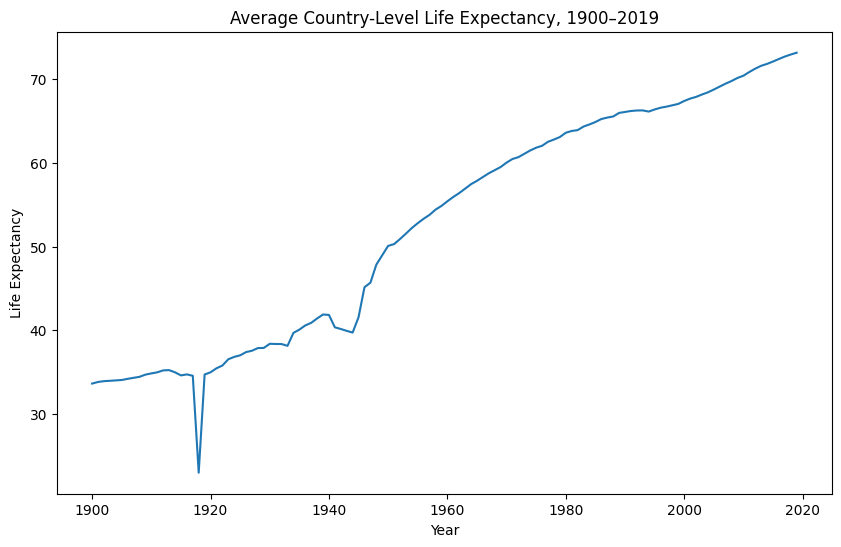

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(global_trends["year"], global_trends["life_expectancy"])
plt.title("Average Country-Level Life Expectancy, 1900–2019")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

### 6.2 Average Country-Level Fertility Rate Over Time

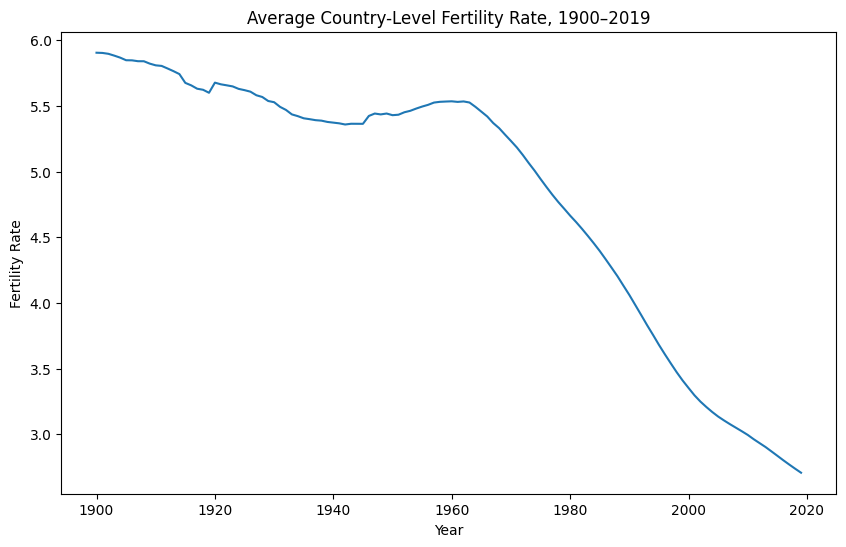

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(global_trends["year"], global_trends["fertility_rate"])
plt.title("Average Country-Level Fertility Rate, 1900–2019")
plt.xlabel("Year")
plt.ylabel("Fertility Rate")
plt.show()

### 6.3 Average Country-Level Income per Person Over Time

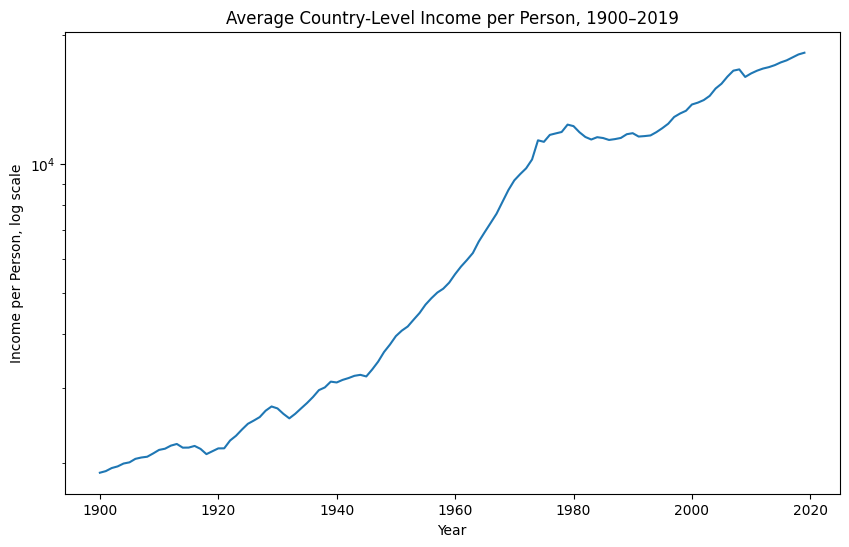

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(global_trends["year"], global_trends["income_per_person"])
plt.yscale("log")
plt.title("Average Country-Level Income per Person, 1900–2019")
plt.xlabel("Year")
plt.ylabel("Income per Person, log scale")
plt.show()

## 7. Income and Life Expectancy

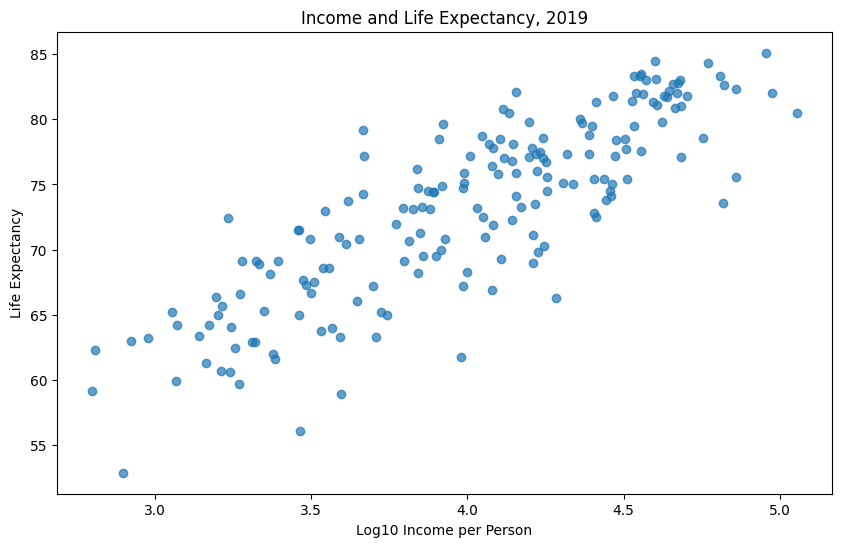

In [14]:
df_2019 = df[df["year"] == 2019].copy()

plt.figure(figsize=(10, 6))
plt.scatter(df_2019["log_income"], df_2019["life_expectancy"], alpha=0.7)
plt.title("Income and Life Expectancy, 2019")
plt.xlabel("Log10 Income per Person")
plt.ylabel("Life Expectancy")
plt.show()

In [15]:
corr_income_life_2019 = df_2019["log_income"].corr(df_2019["life_expectancy"])

print("Correlation between log income and life expectancy in 2019:")
print(round(corr_income_life_2019, 3))

Correlation between log income and life expectancy in 2019:
0.839


In [16]:
selected_years = [1900, 1950, 2000, 2019]

income_life_corr = []

for year in selected_years:
    temp = df[df["year"] == year]
    corr = temp["log_income"].corr(temp["life_expectancy"])
    income_life_corr.append({
        "year": year,
        "income_life_correlation": corr
    })

income_life_corr = pd.DataFrame(income_life_corr)
income_life_corr

,year,income_life_correlation
0,1900,0.63
1,1950,0.69
2,2000,0.79
3,2019,0.84


## 8. Income and Fertility

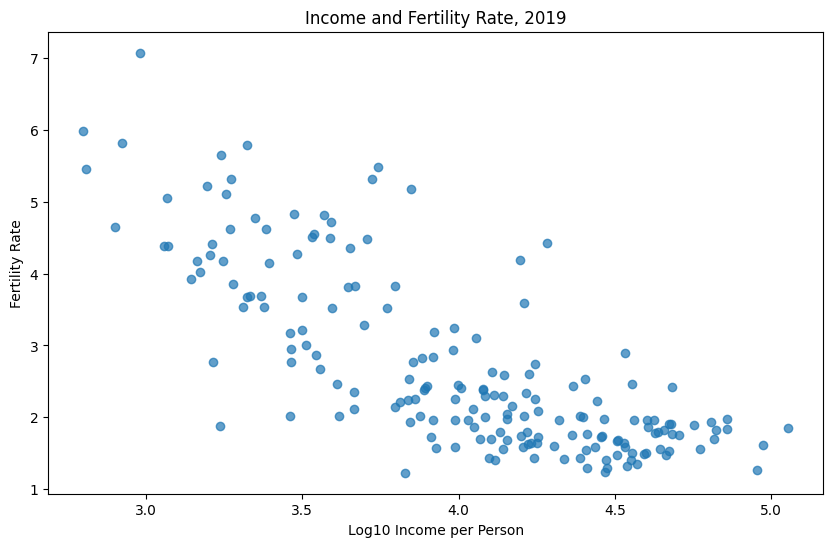

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df_2019["log_income"], df_2019["fertility_rate"], alpha=0.7)
plt.title("Income and Fertility Rate, 2019")
plt.xlabel("Log10 Income per Person")
plt.ylabel("Fertility Rate")
plt.show()

In [18]:
corr_income_fertility_2019 = df_2019["log_income"].corr(df_2019["fertility_rate"])

print("Correlation between log income and fertility rate in 2019:")
print(round(corr_income_fertility_2019, 3))

Correlation between log income and fertility rate in 2019:
-0.775


In [19]:
income_fertility_corr = []

for year in selected_years:
    temp = df[df["year"] == year]
    corr = temp["log_income"].corr(temp["fertility_rate"])
    income_fertility_corr.append({
        "year": year,
        "income_fertility_correlation": corr
    })

income_fertility_corr = pd.DataFrame(income_fertility_corr)
income_fertility_corr

,year,income_fertility_correlation
0,1900,-0.56
1,1950,-0.48
2,2000,-0.73
3,2019,-0.78


## 9. Fertility and Life Expectancy

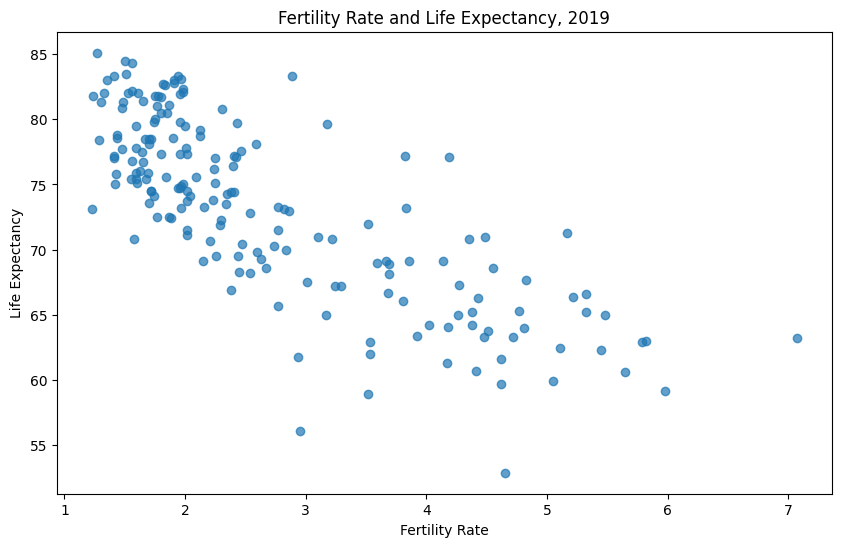

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df_2019["fertility_rate"], df_2019["life_expectancy"], alpha=0.7)
plt.title("Fertility Rate and Life Expectancy, 2019")
plt.xlabel("Fertility Rate")
plt.ylabel("Life Expectancy")
plt.show()

In [21]:
corr_fertility_life_2019 = df_2019["fertility_rate"].corr(df_2019["life_expectancy"])

print("Correlation between fertility rate and life expectancy in 2019:")
print(round(corr_fertility_life_2019, 3))

Correlation between fertility rate and life expectancy in 2019:
-0.782


In [22]:
fertility_life_corr = []

for year in selected_years:
    temp = df[df["year"] == year]
    corr = temp["fertility_rate"].corr(temp["life_expectancy"])
    fertility_life_corr.append({
        "year": year,
        "fertility_life_correlation": corr
    })

fertility_life_corr = pd.DataFrame(fertility_life_corr)
fertility_life_corr

,year,fertility_life_correlation
0,1900,-0.70
1,1950,-0.72
2,2000,-0.81
3,2019,-0.78


## 10. Country-Level Changes, 1900–2019

In [23]:
df_1900 = df[df["year"] == 1900].copy()
df_2019 = df[df["year"] == 2019].copy()

change = df_1900.merge(
    df_2019,
    on="country",
    suffixes=("_1900", "_2019")
)

change.head()

,country,year_1900,fertility_rate_1900,income_per_person_1900,life_expectancy_1900,log_income_1900,year_2019,fertility_rate_2019,income_per_person_2019,life_expectancy_2019,log_income_2019
0,Afghanistan,1900,7.00,1090,29.40,3.04,2019,4.18,1760,64.10,3.25
1,Albania,1900,4.60,1220,35.40,3.09,2019,1.70,12700,78.50,4.10
2,Algeria,1900,6.99,1750,30.20,3.24,2019,2.59,14000,78.10,4.15
3,Angola,1900,7.00,958,29.00,2.98,2019,5.48,5540,65.00,3.74
4,Antigua and Barbuda,1900,4.63,1300,33.80,3.11,2019,2.02,24500,77.30,4.39


In [24]:
change["life_expectancy_change"] = (
    change["life_expectancy_2019"] - change["life_expectancy_1900"]
)

change["fertility_rate_change"] = (
    change["fertility_rate_2019"] - change["fertility_rate_1900"]
)

change["income_growth_ratio"] = (
    change["income_per_person_2019"] / change["income_per_person_1900"]
)

change[[
    "country",
    "life_expectancy_change",
    "fertility_rate_change",
    "income_growth_ratio"
]].describe()

,life_expectancy_change,fertility_rate_change,income_growth_ratio
count,184.00,184.00,184.00
mean,39.57,-3.20,9.61
std,6.62,1.24,8.85
min,21.80,-6.46,0.83
25%,34.67,-4.07,4.10
50%,39.85,-3.29,7.54
75%,44.42,-2.37,11.33
max,57.10,0.24,64.42


In [25]:
top_life_change = (
    change[[
        "country",
        "life_expectancy_1900",
        "life_expectancy_2019",
        "life_expectancy_change"
    ]]
    .sort_values("life_expectancy_change", ascending=False)
    .head(10)
)

top_life_change

,country,life_expectancy_1900,life_expectancy_2019,life_expectancy_change
149,South Korea,25.90,83.00,57.10
86,Kuwait,26.40,83.30,56.90
116,Nicaragua,25.90,79.20,53.30
12,Bangladesh,21.30,73.70,52.40
75,Iran,26.30,77.80,51.50
78,Israel,32.00,83.30,51.30
73,India,18.40,69.50,51.10
143,Singapore,34.20,85.10,50.90
132,Qatar,30.20,80.50,50.30
99,Maldives,31.90,82.10,50.20


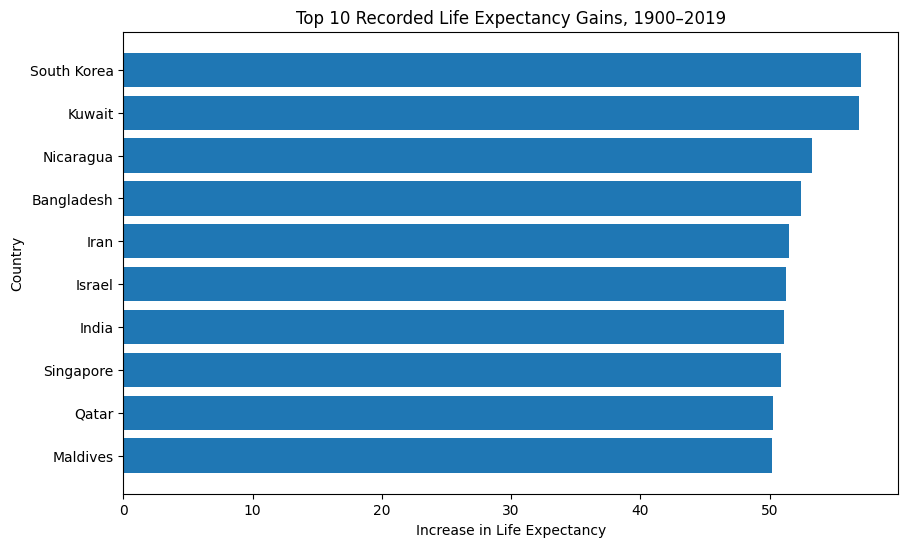

In [26]:
top_life_change_sorted = top_life_change.sort_values("life_expectancy_change")

plt.figure(figsize=(10, 6))
plt.barh(
    top_life_change_sorted["country"],
    top_life_change_sorted["life_expectancy_change"]
)
plt.title("Top 10 Recorded Life Expectancy Gains, 1900–2019")
plt.xlabel("Increase in Life Expectancy")
plt.ylabel("Country")
plt.show()

## 11. Key Findings

1. The average country-level life expectancy increased substantially between 1900 and 2019, rising from around 33.6 years to around 73.2 years in this dataset.

2. The average country-level fertility rate declined over the same period, from around 5.9 in 1900 to around 2.7 in 2019.

3. Average country-level income per person increased over time, although income values were highly skewed. For this reason, log-transformed income was used in the relationship analysis.

4. In 2019, log income and life expectancy showed a strong positive association, with a correlation of approximately 0.84.

5. In 2019, log income and fertility rate showed a strong negative association, with a correlation of approximately -0.78.

6. Fertility rate and life expectancy also showed a strong negative association in 2019, with a correlation of approximately -0.78. This should be interpreted as part of a broader development pattern rather than a direct causal relationship.

7. Some countries recorded life expectancy gains of more than 50 years between 1900 and 2019. These rankings should be interpreted cautiously because country-level averages and historical estimates may hide important context.

## 12. Limitations

- This is an exploratory analysis and does not establish causal relationships.
- The global averages are unweighted country-level averages; each country is given equal weight regardless of population size.
- Income per person is used as a broad development indicator, but it does not capture inequality within countries.
- The dataset does not include other important variables such as healthcare access, education, conflict, governance, child mortality or urbanisation.
- Historical data, especially from the early 20th century, may include estimates and should be interpreted with caution.
- Country-level averages can hide large differences within countries.
- The country-level change analysis compares 1900 and 2019 only, so it does not explain the full path of change within each country.